## The goal of Polars is to provide a lightning fast DataFrame library that:

* Utilizes all available cores on your machine.
* Optimizes queries to reduce unneeded work/memory allocations.
* Handles datasets much larger than your available RAM.
* A consistent and predictable API.
* Adheres to a strict schema (data-types should be known before running the query).


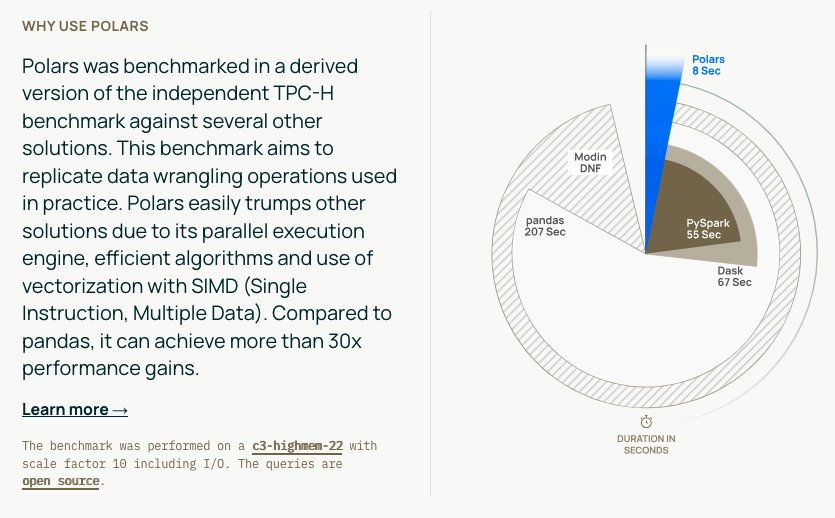

In [ ]:
import polars as pl


CARS = 'data/cars.csv'

In [97]:
df = pl.read_csv(CARS)

ComputeError: could not parse `17.5` as dtype `i64` at column 'mpg' (column number 1)

The current offset in the file is 79 bytes.

You might want to try:
- increasing `infer_schema_length` (e.g. `infer_schema_length=10000`),
- specifying correct dtype with the `schema_overrides` argument
- setting `ignore_errors` to `True`,
- adding `17.5` to the `null_values` list.

Original error: ```remaining bytes non-empty```

### Polars is strict

### Polars is strict about data types. Data type resolution in Polars is dependent on the operation graph, whereas pandas converts types loosely (e.g. new missing data can lead to integer columns being converted to floats). This strictness leads to fewer bugs and more predictable behavior.

In [83]:
df = pl.read_csv(CARS, infer_schema_length=200)
df.head()

mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
f64,i64,f64,str,i64,f64,i64,i64,str
18.0,8,307.0,"""130""",3504,12.0,70,1,"""chevrolet chevelle malibu"""
15.0,8,350.0,"""165""",3693,11.5,70,1,"""buick skylark 320"""
18.0,8,318.0,"""150""",3436,11.0,70,1,"""plymouth satellite"""
16.0,8,304.0,"""150""",3433,12.0,70,1,"""amc rebel sst"""
17.0,8,302.0,"""140""",3449,10.5,70,1,"""ford torino"""


In [84]:
df.describe()

statistic,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
str,f64,f64,f64,str,f64,f64,f64,f64,str
"""count""",398.0,398.0,398.0,"""398""",398.0,398.0,398.0,398.0,"""398"""
"""null_count""",0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""0"""
"""mean""",23.514573,5.454774,193.425879,null,2970.424623,15.56809,76.01005,1.572864,null
"""std""",7.815984,1.701004,104.269838,null,846.841774,2.757689,3.697627,0.802055,null
"""min""",9.0,3.0,68.0,"""100""",1613.0,8.0,70.0,1.0,"""amc ambassador brougham"""
"""25%""",17.5,4.0,104.0,null,2223.0,13.8,73.0,1.0,null
"""50%""",23.0,4.0,151.0,null,2807.0,15.5,76.0,1.0,null
"""75%""",29.0,8.0,262.0,null,3609.0,17.2,79.0,2.0,null
"""max""",46.6,8.0,455.0,"""?""",5140.0,24.8,82.0,3.0,"""vw rabbit custom"""


In [85]:
lf = pl.scan_csv(CARS, infer_schema_length=200)

In [86]:
lf.dtypes

/var/folders/z_/wcdtwfs54fz78jpj_zcpfn_00000gn/T/ipykernel_74022/1684367775.py:1: PerformanceWarning: Determining the data types of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().dtypes()` to get the data types without this warning.
  lf.dtypes


[Float64, Int64, Float64, String, Int64, Float64, Int64, Int64, String]

In [87]:
lf.collect_schema()

Schema([('mpg', Float64),
        ('cylinders', Int64),
        ('displacement', Float64),
        ('horsepower', String),
        ('weight', Int64),
        ('acceleration', Float64),
        ('model year', Int64),
        ('origin', Int64),
        ('car name', String)])

In [ ]:
lf_step_1 = lf.filter(pl.col('mpg') <= 20).select(['car name',
                                                'model year',
                                                'horsepower',
                                                'mpg'])

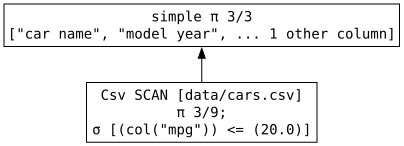

In [89]:
lf_step_1.show_graph()

In [90]:
lf_step_2 = lf_step_1.group_by('car name').agg(
    avg_mpg = pl.col('mpg').mean(),
    n_cars = pl.len()
)

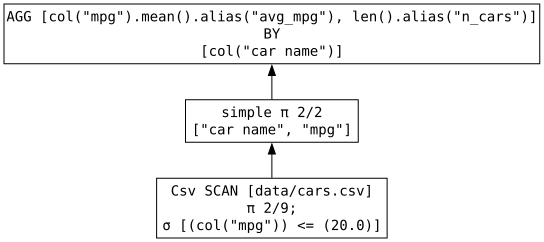

In [91]:
lf_step_2.show_graph()

### Polars will push the filter and column selection down to the CSV scan. Pandas will typically read the CSV first, then widen the operations.

In [92]:
df = lf_step_2.collect()
df.describe()

statistic,car name,avg_mpg,n_cars
str,str,f64,f64
"""count""","""126""",126.0,126.0
"""null_count""","""0""",0.0,0.0
"""mean""",null,15.98082,1.269841
"""std""",null,2.662019,0.674243
"""min""","""amc ambassador brougham""",9.0,1.0
"""25%""",null,14.0,1.0
"""50%""",null,16.0,1.0
"""75%""",null,18.1,1.0
"""max""","""volvo 264gl""",20.0,5.0


In [96]:
df = lf_step_2.collect().head(10)